In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("screentime.csv")

In [3]:
print(df.shape)

(9712, 8)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [5]:
print(df.head())

   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN          Urban  
4     Poor Sleep, Anx

In [6]:
df["Health_Impacts"] = df["Health_Impacts"].fillna("No Health Impact")

In [7]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nMissing percentage:\n", missing_percent[missing_percent > 0])


Missing percentage:
 Series([], dtype: float64)


In [8]:
print(df["Health_Impacts"].unique())

['Poor Sleep, Eye Strain' 'Poor Sleep' 'No Health Impact'
 'Poor Sleep, Anxiety' 'Poor Sleep, Obesity Risk' 'Eye Strain'
 'Obesity Risk' 'Anxiety' 'Poor Sleep, Anxiety, Obesity Risk'
 'Eye Strain, Obesity Risk' 'Eye Strain, Anxiety, Obesity Risk'
 'Anxiety, Obesity Risk' 'Poor Sleep, Eye Strain, Obesity Risk'
 'Poor Sleep, Eye Strain, Anxiety'
 'Poor Sleep, Eye Strain, Anxiety, Obesity Risk' 'Eye Strain, Anxiety']


In [9]:
print("\nAfter cleaning:\n", df.isnull().sum())


After cleaning:
 Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64


In [10]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Duplicate rows: 44
After removing duplicates: (9668, 8)


In [11]:
# checking if there any inconsistent data

print(df["Gender"].unique())
print(df["Primary_Device"].unique())
print(df["Urban_or_Rural"].unique())
print(df["Exceeded_Recommended_Limit"].unique())
print(df["Health_Impacts"].unique())

['Male' 'Female']
['Smartphone' 'Laptop' 'TV' 'Tablet']
['Urban' 'Rural']
[ True False]
['Poor Sleep, Eye Strain' 'Poor Sleep' 'No Health Impact'
 'Poor Sleep, Anxiety' 'Poor Sleep, Obesity Risk' 'Eye Strain'
 'Obesity Risk' 'Anxiety' 'Poor Sleep, Anxiety, Obesity Risk'
 'Eye Strain, Obesity Risk' 'Eye Strain, Anxiety, Obesity Risk'
 'Anxiety, Obesity Risk' 'Poor Sleep, Eye Strain, Obesity Risk'
 'Poor Sleep, Eye Strain, Anxiety'
 'Poor Sleep, Eye Strain, Anxiety, Obesity Risk' 'Eye Strain, Anxiety']


In [12]:
# Derived Columns
# Age Band using Age column

df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[5, 8, 12, 16],
    labels=['Young Kids', 'Pre-Teens', 'Teenagers']
)
print(df["Age_Band"].value_counts())

Age_Band
Teenagers     3543
Pre-Teens     3468
Young Kids     900
Name: count, dtype: int64


In [13]:
# percentage of kids who exceeded limit in each age group

print(df.groupby("Age_Band", observed=True)["Exceeded_Recommended_Limit"].mean()* 100)

Age_Band
Young Kids    75.888889
Pre-Teens     81.978085
Teenagers     90.036692
Name: Exceeded_Recommended_Limit, dtype: float64


In [14]:
# Screen Time Category
# Low (0–2 hrs) Moderate (2–4 hrs) High (4–6 hrs) Very High (>6 hrs)

df["Screen_Time_Level"] = pd.cut(
    df["Avg_Daily_Screen_Time_hr"],
    bins=[0, 2, 4, 6, 10],
    labels=["Low", "Moderate", "High", "Very High"]
)
df[["Avg_Daily_Screen_Time_hr", "Screen_Time_Level"]].head()

,Avg_Daily_Screen_Time_hr,Screen_Time_Level
0,3.99,Moderate
1,4.61,High
2,3.73,Moderate
3,1.21,Low
4,5.89,High


In [15]:
# counting of kids in screen time level

df["Screen_Time_Level"].value_counts()

Screen_Time_Level
High         4589
Moderate     2927
Very High    1326
Low           604
Name: count, dtype: int64

In [16]:
# Risk Level categorical column using Exceeded_Recommended_Limit column

df["Risk_Level"] = df["Exceeded_Recommended_Limit"].apply(
    lambda x: "At Risk" if x else "Safe"
)
print(df[["Exceeded_Recommended_Limit", "Risk_Level"]].head())

   Exceeded_Recommended_Limit Risk_Level
0                        True    At Risk
1                        True    At Risk
2                        True    At Risk
3                       False       Safe
4                        True    At Risk


In [17]:
# counting of kids in risk level based

print(df["Risk_Level"].value_counts())

Risk_Level
At Risk    8292
Safe       1376
Name: count, dtype: int64


In [18]:
# Health_Severity derived col using Health_Impacts col

df["Health_Severity"] = df["Health_Impacts"].apply(
    lambda x: "No Impact" if x == "No Health Impact"
    else "Mild" if len(str(x).split(",")) == 1
    else "Moderate" if len(str(x).split(",")) == 2
    else "Severe"
)
print(df[["Health_Impacts", "Health_Severity"]].head())

           Health_Impacts Health_Severity
0  Poor Sleep, Eye Strain        Moderate
1              Poor Sleep            Mild
2              Poor Sleep            Mild
3        No Health Impact       No Impact
4     Poor Sleep, Anxiety        Moderate


In [19]:
# counting of kids in health condition based

print(df["Health_Severity"].value_counts())

Health_Severity
Mild         3545
No Impact    3180
Moderate     2347
Severe        596
Name: count, dtype: int64


In [20]:
# Digital_Balance

df["Digital_Balance"] = df["Educational_to_Recreational_Ratio"].apply(
    lambda x: "Balanced" if x == 1
    else "Mostly Recreational" if x < 0.5
    else "Moderately Recreational"
)
print(df[["Educational_to_Recreational_Ratio", "Digital_Balance"]].head())

   Educational_to_Recreational_Ratio      Digital_Balance
0                               0.42  Mostly Recreational
1                               0.30  Mostly Recreational
2                               0.32  Mostly Recreational
3                               0.39  Mostly Recreational
4                               0.49  Mostly Recreational


In [21]:
print(df["Digital_Balance"].value_counts())

Digital_Balance
Mostly Recreational        8085
Moderately Recreational    1583
Name: count, dtype: int64


In [22]:
# creating Screen_Size_Type derived col using primary device col

df["Screen_Size_Type"] = df["Primary_Device"].apply(
    lambda x: "Small Screen" if x.lower() == "smartphone"
    else "Medium Screen" if x.lower() == "tablet"
    else "Large Screen"
)
df[["Primary_Device", "Screen_Size_Type"]].head()

,Primary_Device,Screen_Size_Type
0,Smartphone,Small Screen
1,Laptop,Large Screen
2,TV,Large Screen
3,Laptop,Large Screen
4,Smartphone,Small Screen


In [23]:
# weekday | weekend derived col

df["Day_Type"] = df["Avg_Daily_Screen_Time_hr"].apply(
    lambda x: "Weekend" if x > 3 else "Weekday"
)

df["Day_Type"].value_counts()

Day_Type
Weekend    7950
Weekday    1718
Name: count, dtype: int64

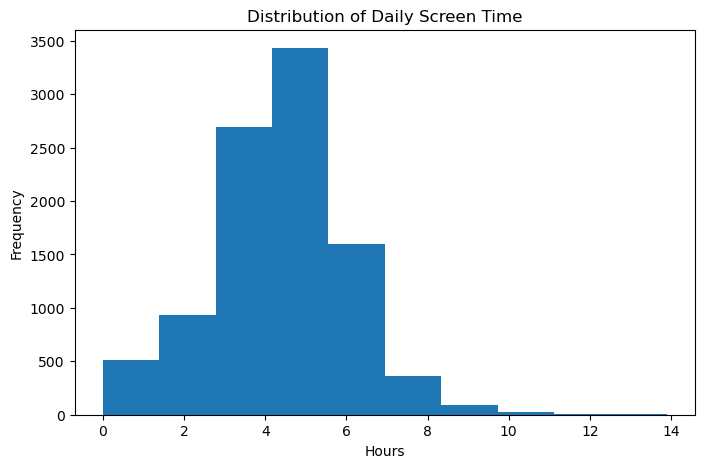

In [24]:
# UNIVARIATE ANALYSIS And BIVARIATE ANALYSIS
# Screen Time Distribution

plt.figure(figsize=(8,5))
plt.hist(df['Avg_Daily_Screen_Time_hr'])
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

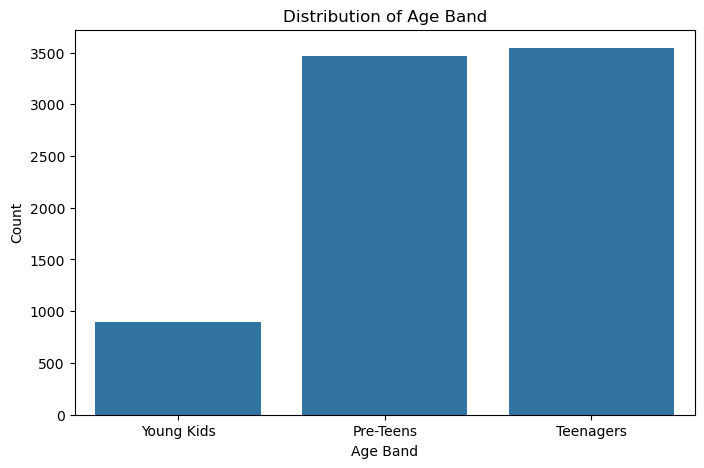

In [25]:
# which age group appears more in dataset

plt.figure(figsize=(8,5))
sns.countplot(x='Age_Band', data=df)
plt.title("Distribution of Age Band")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

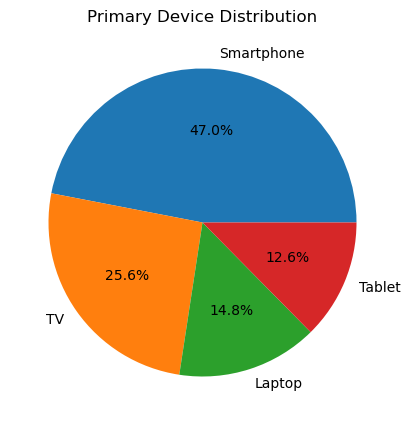

In [26]:
# Distribution of Device usage

plt.figure(figsize=(5,5))
df["Primary_Device"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Primary Device Distribution")
plt.ylabel("")
plt.show()

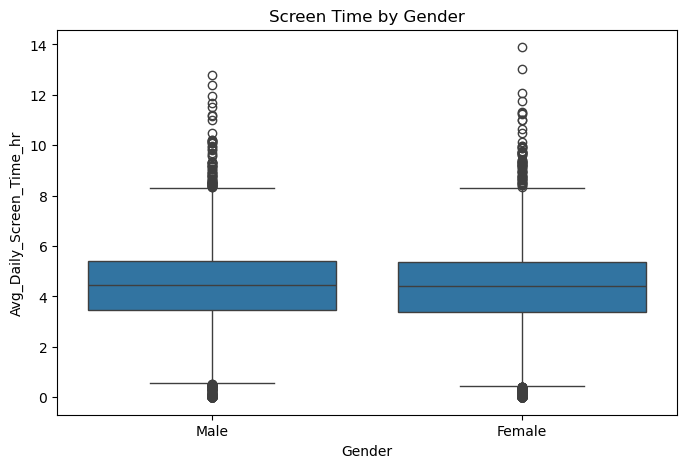

In [27]:
# BIVARIATE ANALYSIS
# Screen Time by Gender

plt.figure(figsize=(8,5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time by Gender")
plt.show()

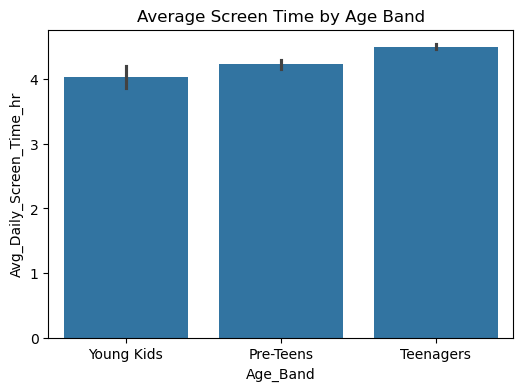

In [28]:
# (num vs cat)

plt.figure(figsize=(6,4))
sns.barplot(x="Age_Band",y="Avg_Daily_Screen_Time_hr",data=df)
plt.title("Average Screen Time by Age Band")
plt.show()

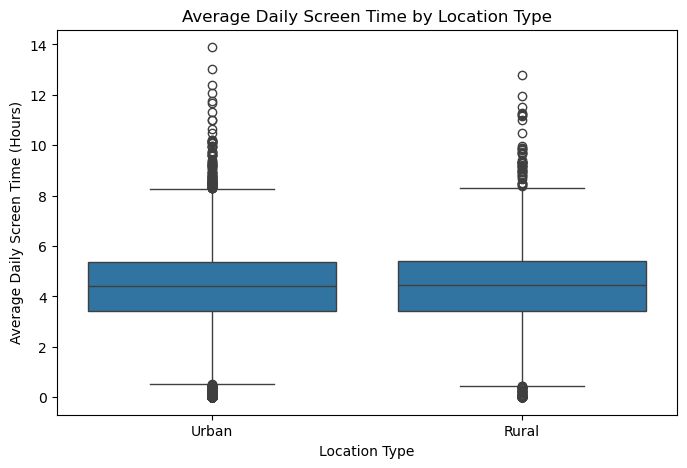

In [29]:
# Screen time by location type

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Urban_or_Rural",
    y="Avg_Daily_Screen_Time_hr",
    data=df
)
plt.title("Average Daily Screen Time by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

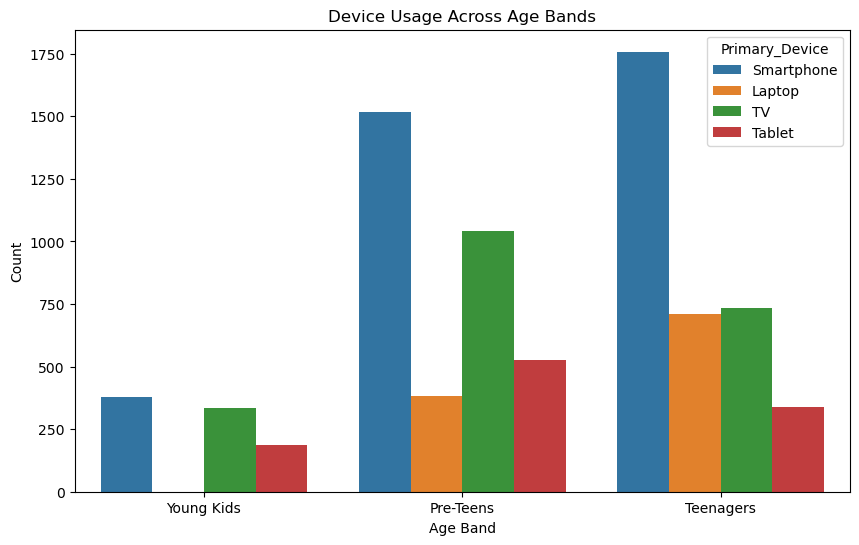

In [30]:
# Device usage across age bands

plt.figure(figsize=(10,6))
sns.countplot(x="Age_Band", hue="Primary_Device", data=df)
plt.title("Device Usage Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

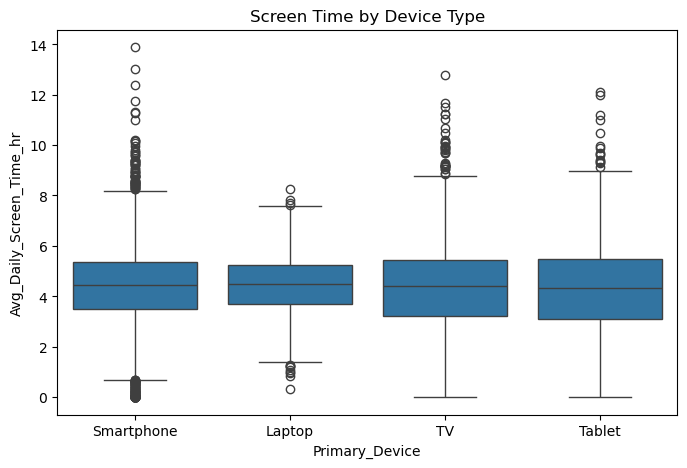

In [31]:
# "Screen Time by Device Type

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Primary_Device",
    y="Avg_Daily_Screen_Time_hr",
    data=df
)
plt.title("Screen Time by Device Type")
plt.show()

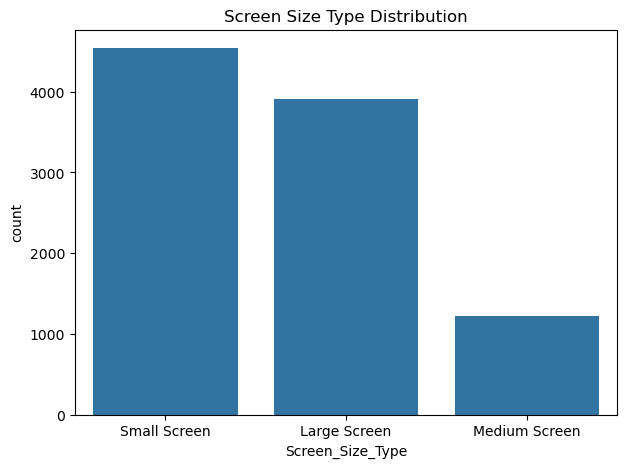

In [32]:
# Screen Size Type Distribution

plt.figure(figsize=(7,5))
sns.countplot(x="Screen_Size_Type", data=df)
plt.title("Screen Size Type Distribution")
plt.show()

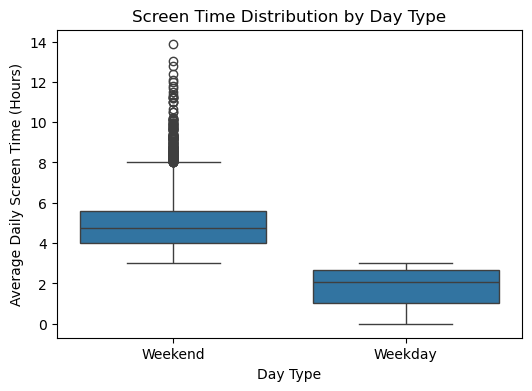

In [33]:
# (Num VS Cat)

plt.figure(figsize=(6,4))
sns.boxplot(x="Day_Type",
            y="Avg_Daily_Screen_Time_hr",
            data=df)
plt.title("Screen Time Distribution by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

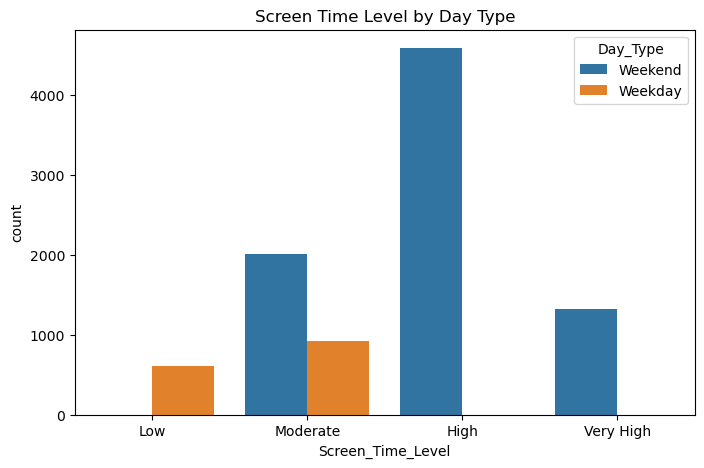

In [34]:
# cat vs cat

plt.figure(figsize=(8,5))
sns.countplot(
    x="Screen_Time_Level",
    hue="Day_Type",
    data=df
)
plt.title("Screen Time Level by Day Type")
plt.show()

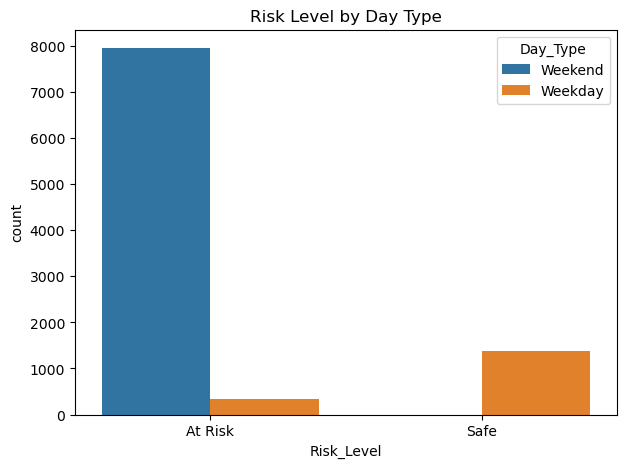

In [35]:
# cat vs cat

plt.figure(figsize=(7,5))
sns.countplot(
    x="Risk_Level",
    hue="Day_Type",
    data=df
)
plt.title("Risk Level by Day Type")
plt.show()

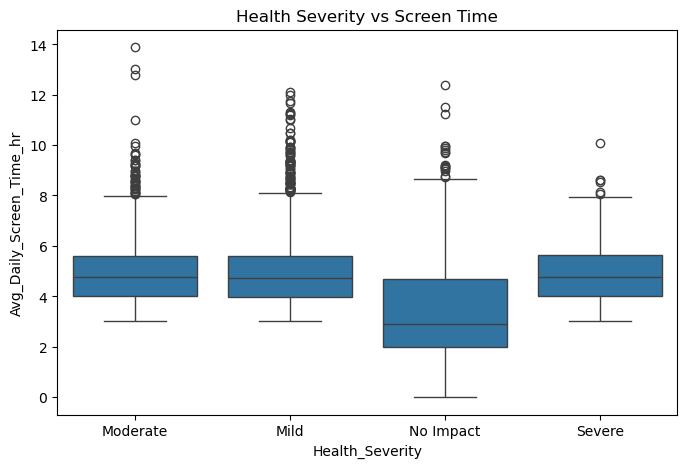

In [36]:
# num vs cat

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Health_Severity",
    y="Avg_Daily_Screen_Time_hr",
    data=df
)
plt.title("Health Severity vs Screen Time")
plt.show()

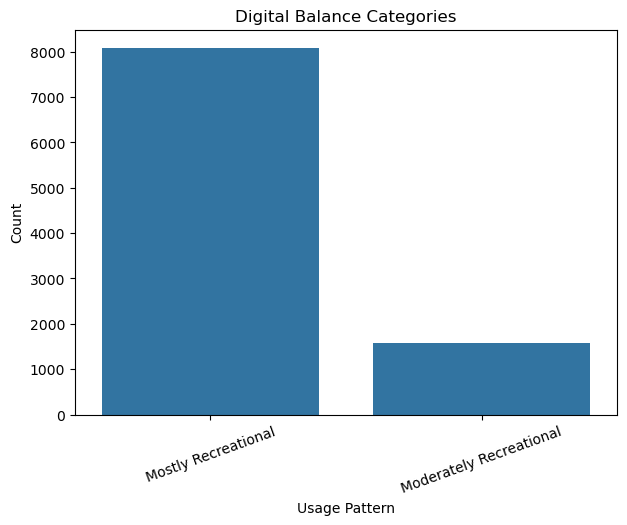

In [37]:
# learning vs entertainment balance

plt.figure(figsize=(7,5))
sns.countplot(x="Digital_Balance", data=df)
plt.title("Digital Balance Categories")
plt.xlabel("Usage Pattern")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

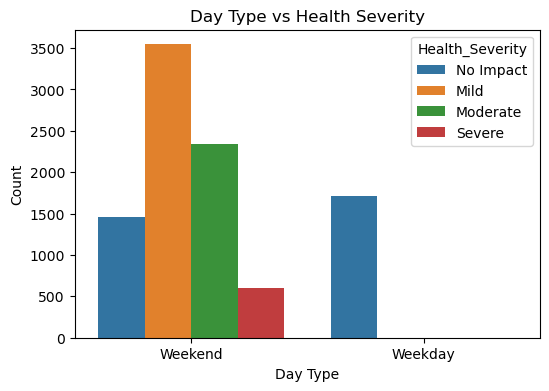

In [38]:
# (Cat VS Cat)

plt.figure(figsize=(6,4))
sns.countplot(x="Day_Type",
              hue="Health_Severity",
              data=df,
              hue_order=["No Impact","Mild","Moderate","Severe"])
plt.title("Day Type vs Health Severity")
plt.xlabel("Day Type")
plt.ylabel("Count")
plt.show()


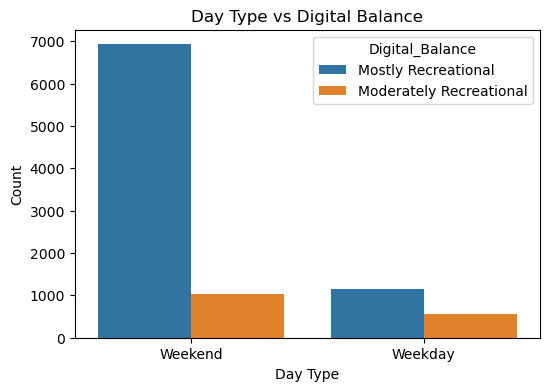

In [39]:
# (Cat VS Cat)

plt.figure(figsize=(6,4))
sns.countplot(x="Day_Type",
              hue="Digital_Balance",
              data=df)
plt.title("Day Type vs Digital Balance")
plt.xlabel("Day Type")
plt.ylabel("Count")
plt.show()

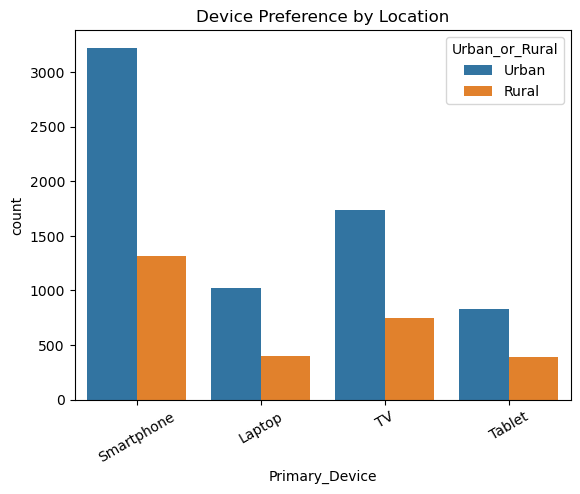

In [40]:
# Device vs Location(Cat VS Cat)

sns.countplot(x='Primary_Device', hue='Urban_or_Rural', data=df)
plt.title("Device Preference by Location")
plt.xticks(rotation=30)
plt.show()

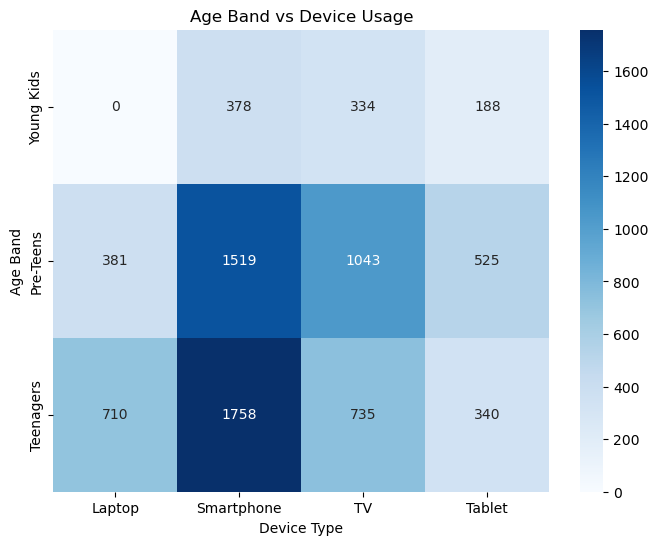

In [41]:
# Cohort and Segment Analysis 
# which age group uses which device the most.

cohort_device = pd.crosstab(df["Age_Band"], df["Primary_Device"])
plt.figure(figsize=(8,6))
sns.heatmap(cohort_device, annot=True, cmap="Blues", fmt="d")
plt.title("Age Band vs Device Usage")
plt.xlabel("Device Type")
plt.ylabel("Age Band")
plt.show()

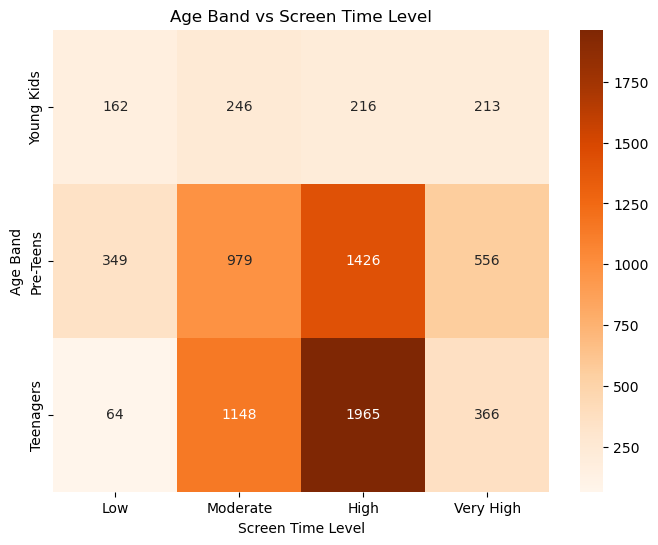

In [42]:
# Identify which age group has higher screen time.

age_screen = pd.crosstab(df["Age_Band"], df["Screen_Time_Level"])

plt.figure(figsize=(8,6))
sns.heatmap(age_screen, annot=True, cmap="Oranges", fmt="d")
plt.title("Age Band vs Screen Time Level")
plt.xlabel("Screen Time Level")
plt.ylabel("Age Band")
plt.show()

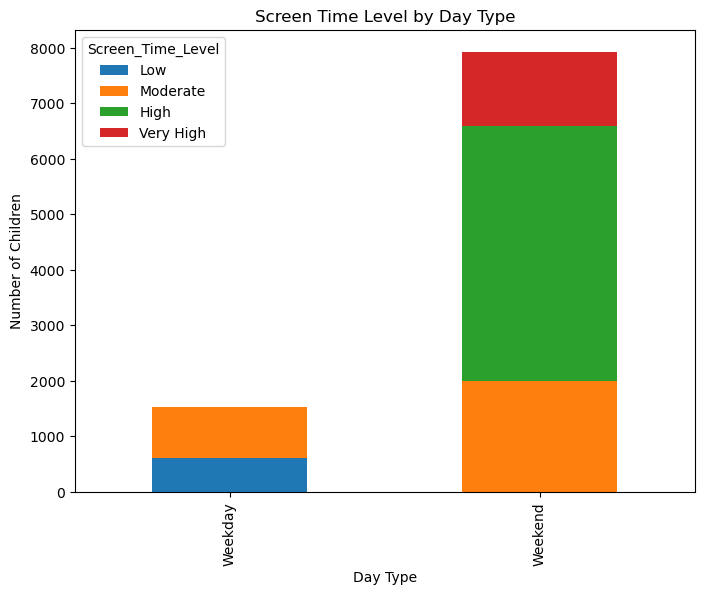

In [43]:
# Compare weekday vs weekend screen time.

day_screen = pd.crosstab(df["Day_Type"], df["Screen_Time_Level"])

day_screen.plot(kind="bar", stacked=True, figsize=(8,6))

plt.title("Screen Time Level by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Number of Children")
plt.show()

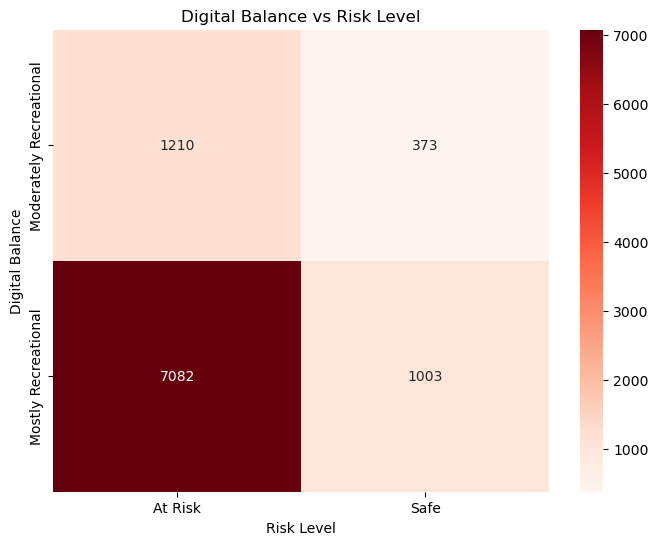

In [44]:
# Check if recreational usage leads to higher risk.

balance_risk = pd.crosstab(df["Digital_Balance"], df["Risk_Level"])

plt.figure(figsize=(8,6))
sns.heatmap(balance_risk, annot=True, cmap="Reds", fmt="d")

plt.title("Digital Balance vs Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Digital Balance")
plt.show()

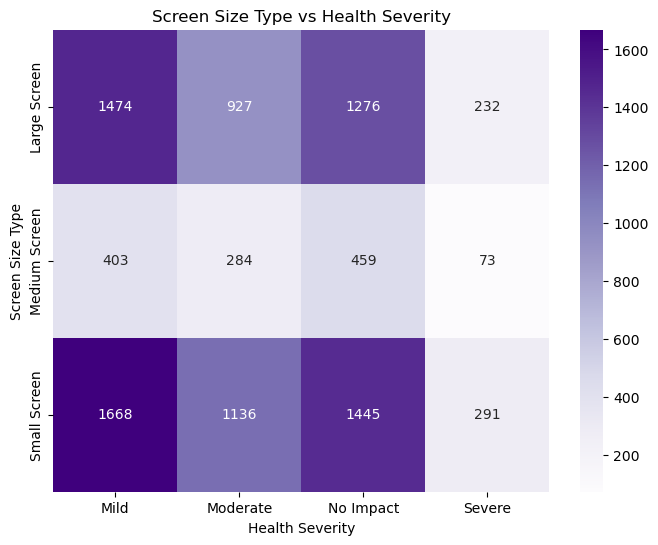

In [45]:
# Check if small screens affect health more.

screen_health = pd.crosstab(df["Screen_Size_Type"], df["Health_Severity"])

plt.figure(figsize=(8,6))
sns.heatmap(screen_health, annot=True, cmap="Purples", fmt="d")

plt.title("Screen Size Type vs Health Severity")
plt.xlabel("Health Severity")
plt.ylabel("Screen Size Type")
plt.show()

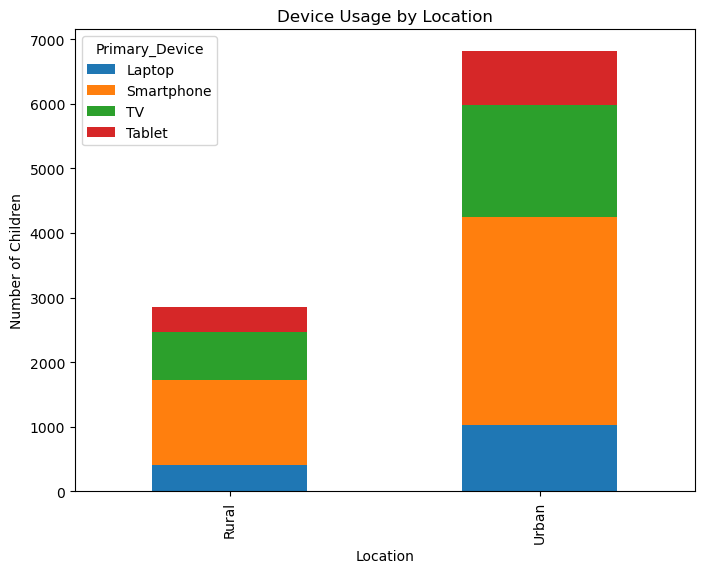

In [46]:
# Compare device usage by location.

location_device = pd.crosstab(df["Urban_or_Rural"], df["Primary_Device"])

location_device.plot(kind="bar", stacked=True, figsize=(8,6))

plt.title("Device Usage by Location")
plt.xlabel("Location")
plt.ylabel("Number of Children")
plt.show()

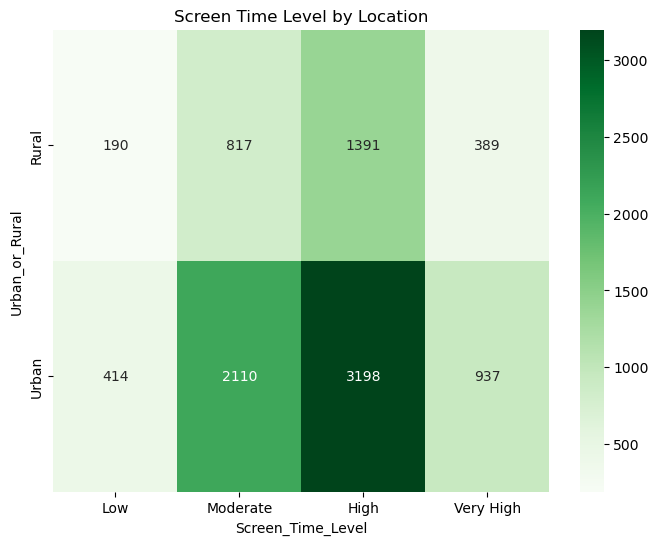

In [47]:
# Compare screen exposure by location.

location_screen = pd.crosstab(df["Urban_or_Rural"], df["Screen_Time_Level"])

plt.figure(figsize=(8,6))
sns.heatmap(location_screen, annot=True, cmap="Greens", fmt="d")

plt.title("Screen Time Level by Location")
plt.show()